# **Isabel Nieto, Leonardo Tovar**


## **Taller: Clasificación de Trazas de Partículas**

Construya un clasificador supervisado capaz de diferenciar entre distintos tipos de partículas a partir de imágenes de sus trazas. Para ello, se trabajará con el conjunto de datos previamente cargado, organizadas en carpetas según la clase de partícula correspondiente:

*   Electrón
*   Muón
*   Protón
*   Neutrino
*   Quark
*   Tau

Desarrolle un flujo completo de trabajo en aprendizaje automático, desde la carga y exploración de los datos hasta la evaluación de un modelo de clasificación. El ejercicio permitirá comprender los principales pasos de un proyecto de machine learning aplicado al análisis de imágenes.

1. Carga de datos.
2. Exploración inicial: Se deberán mostrar algunas imágenes representativas de cada clase, imprimir las dimensiones de X y y, y analizar la distribución de las clases en el conjunto de datos.
3. Será necesario normalizar los valores de los píxeles en el rango [0, 1], preparar los datos para el modelo y dividirlos en conjuntos de entrenamiento y prueba (por ejemplo, 80% entrenamiento y 20% prueba).
4. Implemente al menos un modelo de clasificación supervisada. Se recomienda iniciar con modelos clásicos como: Regresión Logística y SVM.
5. Evaluación del modelo: El desempeño del clasificador deberá medirse calculando la precisión en el conjunto de prueba. Además, se deberá generar una matriz de confusión para analizar qué clases resultan más fáciles o difíciles de distinguir. Pueden calcular métricas adicionales como la exactitud por clase o las curvas ROC.
6. Discusión y conclusiones: Finalmente, deberá presentar una reflexión sobre los resultados obtenidos, identificando fortalezas y debilidades del clasificador. También deberá proponer mejoras posibles.

## Cargar datos

In [31]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import LabelEncoder


def cargar_datos(zip_path="CERN_dataset.zip", carpeta_salida="CERN_datos"):
    #1. Proceso para descomprimir el archivo ZIP
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(carpeta_salida)
    X = []
    y = []
    #2. Recorrer las carpetas con las imagenes
    for clase in os.listdir(carpeta_salida):
        clase_path = os.path.join(carpeta_salida, clase)
        if os.path.isdir(clase_path):
            for img_name in os.listdir(clase_path):
                img_path = os.path.join(clase_path, img_name)

                # 3. Procedimiento para cargar imagenes en escala de grises
                img = Image.open(img_path).convert("L")
                X.append(np.array(img))
                y.append(clase)  # etiqueta = nombre de la carpeta

    X = np.array(X)
    return X, y

In [23]:
X, y = cargar_datos("CERN_dataset.zip")
print(f"Se cargaron {len(X)} imágenes.")
print(f"Clases encontradas: {set(y)}")
print("Dimensiones de las imágenes:", X.shape)

Se cargaron 3000 imágenes.
Clases encontradas: {'neutrino', 'electron', 'quark', 'tau', 'muon', 'proton'}
Dimensiones de las imágenes: (3000, 64, 64)


## Exploración inicial del dataset

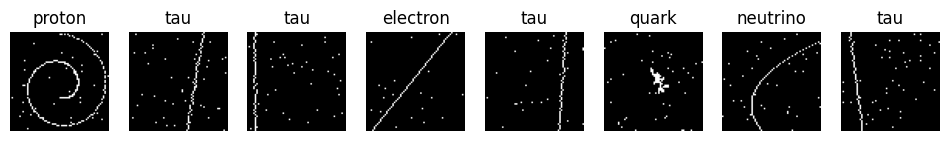

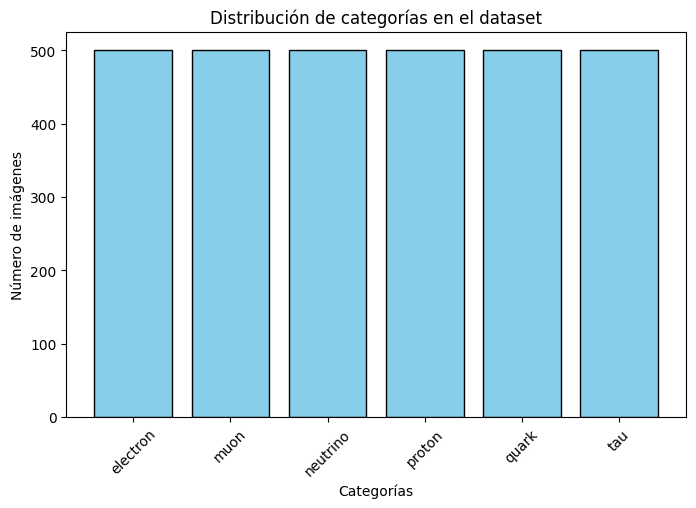

In [24]:
# Paso 2: Exploración inicial

# 1. Cargar datos
imagenes, etiquetas = cargar_datos()

# 2. Función para mostrar imágenes aleatorias
def mostrar_muestras(imgs, labs, n=6):
    indices = np.random.choice(len(imgs), n, replace=False)  # elegir imágenes al azar
    plt.figure(figsize=(12, 4))

    for i, idx in enumerate(indices):
        plt.subplot(1, n, i+1)
        plt.imshow(imgs[idx], cmap="gray")
        plt.title(labs[idx])
        plt.axis("off")
    plt.show()

# Mostrar ejemplos aleatorios
mostrar_muestras(imagenes, etiquetas, n=8)

# 3. Distribución de clases
from collections import Counter

frecuencias = Counter(etiquetas)

plt.figure(figsize=(8,5))
plt.bar(frecuencias.keys(), frecuencias.values(), color="skyblue", edgecolor="black")
plt.title("Distribución de categorías en el dataset")
plt.xlabel("Categorías")
plt.ylabel("Número de imágenes")
plt.xticks(rotation=45)
plt.show()


## Normalizacion y division de conjuntos de entrenamiento

In [25]:
# Normalizar valores de píxeles al rango [0, 1]
imagenes_norm = imagenes.astype("float32") / 255.0

# Convertir etiquetas a un array de NumPy
etiquetas = np.array(etiquetas)

# Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    imagenes_norm, etiquetas, test_size=0.2, random_state=42, stratify=etiquetas
)

print("Tamaño del conjunto de entrenamiento:", X_train.shape)
print("Tamaño del conjunto de prueba:", X_test.shape)

Tamaño del conjunto de entrenamiento: (2400, 64, 64)
Tamaño del conjunto de prueba: (600, 64, 64)


## Clasificacion de los datos (Regresion Logistica, SVM)

In [28]:
# Aplanar las imágenes (pasar de 2D a vector 1D) para usarlas en modelos clásicos
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat  = X_test.reshape(len(X_test), -1)

# ---- Modelo 1: Regresión Logística ----
log_reg = LogisticRegression(max_iter=1000)  # max_iter alto para asegurar convergencia
log_reg.fit(X_train_flat, y_train)

y_pred_lr = log_reg.predict(X_test_flat)
print("=== Regresión Logística ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

# ---- Modelo 2: SVM ----
svm_model = SVC(kernel="linear")  # kernel puede cambiarse a 'rbf' para más complejidad
svm_model.fit(X_train_flat, y_train)

y_pred_svm = svm_model.predict(X_test_flat)
print("\n=== SVM ===")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

=== Regresión Logística ===
Accuracy: 0.5616666666666666
              precision    recall  f1-score   support

    electron       0.29      0.33      0.31       100
        muon       0.31      0.32      0.31       100
    neutrino       0.40      0.41      0.41       100
      proton       0.99      0.98      0.98       100
       quark       0.98      0.97      0.97       100
         tau       0.43      0.36      0.39       100

    accuracy                           0.56       600
   macro avg       0.57      0.56      0.56       600
weighted avg       0.57      0.56      0.56       600


=== SVM ===
Accuracy: 0.56
              precision    recall  f1-score   support

    electron       0.30      0.36      0.33       100
        muon       0.30      0.28      0.29       100
    neutrino       0.40      0.39      0.39       100
      proton       1.00      1.00      1.00       100
       quark       0.99      0.95      0.97       100
         tau       0.42      0.38      0.40    

## Evaluación del modelo

=== Evaluación Regresión Logística ===
Precisión global (accuracy): 0.5617


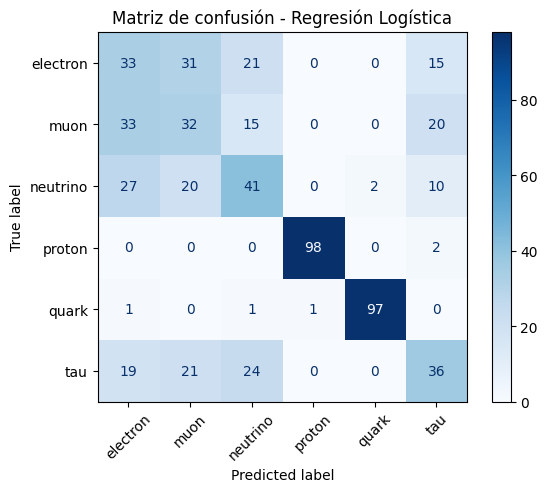


=== Evaluación SVM ===
Precisión global (accuracy): 0.5600


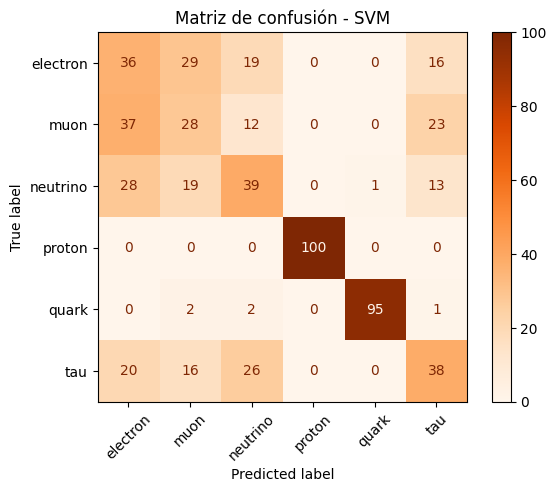

In [30]:
# Paso 5: Evaluación del modelo

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ---- Evaluación de Regresión Logística ----
print("=== Evaluación Regresión Logística ===")
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Precisión global (accuracy): {acc_lr:.4f}")

cm_lr = confusion_matrix(y_test, y_pred_lr, labels=log_reg.classes_)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=log_reg.classes_)
disp_lr.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de confusión - Regresión Logística")
plt.show()


# ---- Evaluación de SVM ----
print("\n=== Evaluación SVM ===")
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"Precisión global (accuracy): {acc_svm:.4f}")

cm_svm = confusion_matrix(y_test, y_pred_svm, labels=svm_model.classes_)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=svm_model.classes_)
disp_svm.plot(cmap="Oranges", xticks_rotation=45)
plt.title("Matriz de confusión - SVM")
plt.show()


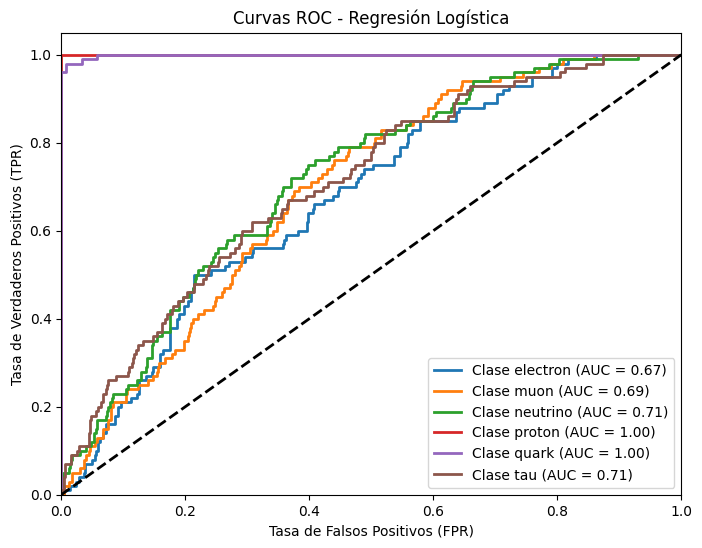

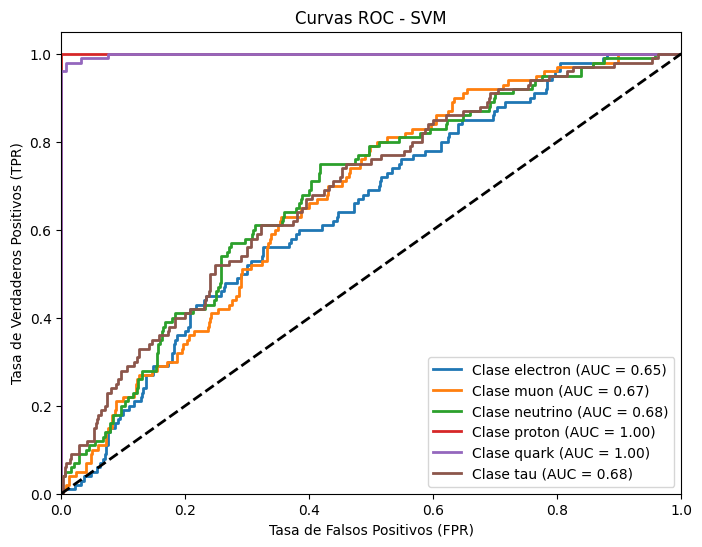

In [33]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Binarizar etiquetas para ROC multiclase
y_test_bin = label_binarize(y_test_enc, classes=range(len(le.classes_)))
n_clases = y_test_bin.shape[1]

# ---- Regresión Logística (OvR) ----
ovr_lr = OneVsRestClassifier(LogisticRegression(max_iter=1000))
ovr_lr.fit(X_train_flat, y_train_enc)
y_score_lr = ovr_lr.decision_function(X_test_flat)

# ---- SVM (OvR) ----
ovr_svm = OneVsRestClassifier(SVC(kernel="linear", probability=True))
ovr_svm.fit(X_train_flat, y_train_enc)
y_score_svm = ovr_svm.decision_function(X_test_flat)

# Función auxiliar para graficar ROC
def plot_roc_curves(y_test_bin, y_score, modelo, clases):
    plt.figure(figsize=(8,6))
    for i in range(n_clases):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"Clase {clases[i]} (AUC = {roc_auc:.2f})")

    plt.plot([0,1], [0,1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("Tasa de Falsos Positivos (FPR)")
    plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
    plt.title(f"Curvas ROC - {modelo}")
    plt.legend(loc="lower right")
    plt.show()

# Graficar ROC para cada modelo
plot_roc_curves(y_test_bin, y_score_lr, "Regresión Logística", le.classes_)
plot_roc_curves(y_test_bin, y_score_svm, "SVM", le.classes_)